[INFO] Weights already downloaded
IMPROVED ASTROMER PIPELINE WITH SYNTHETIC DATA

[1/6] Generating synthetic data...
Generating 500 AGN and 500 TDE light curves...
Total: 1000 light curves

[2/6] Plotting example light curves...
Saved examples to synthetic_examples.png

[3/6] Preprocessing...
Preprocessing light curves...
Preprocessing complete

[4/6] Fine-tuning Astromer...

Fine-tuning Astromer on synthetic data (50 epochs)...


2025-10-08 10:52:16.654021: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
/Users/nmearl/code/fluctuant/.venv/lib/python3.9/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['output', 'mask_out', 'label', 'id'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)
EPOCH 49 - ES COUNT: 8.0/40 train mse: 0.0633 - val mse: 0.1003: 100%|██████████| 50/50 [03:36<00:00,  4.34s/it] 


Fine-tuning complete!

[5/6] Generating Astromer embeddings...
Generating enhanced embeddings...
[INFO] Loading numpy arrays
[INFO] no masking
Generated enhanced embeddings: (1000, 1280)

[6/6] Training classifier...

Training classifier...

Classification Report:
              precision    recall  f1-score   support

         AGN      0.533     0.533     0.533       150
         TDE      0.533     0.533     0.533       150

    accuracy                          0.533       300
   macro avg      0.533     0.533     0.533       300
weighted avg      0.533     0.533     0.533       300


Confusion Matrix:
                Predicted
                AGN    TDE
Actual  AGN      80     70
        TDE      70     80

ROC AUC Score: 0.552

Generating visualizations...

Generating t-SNE visualization...
Saved visualization to embeddings_tsne.png


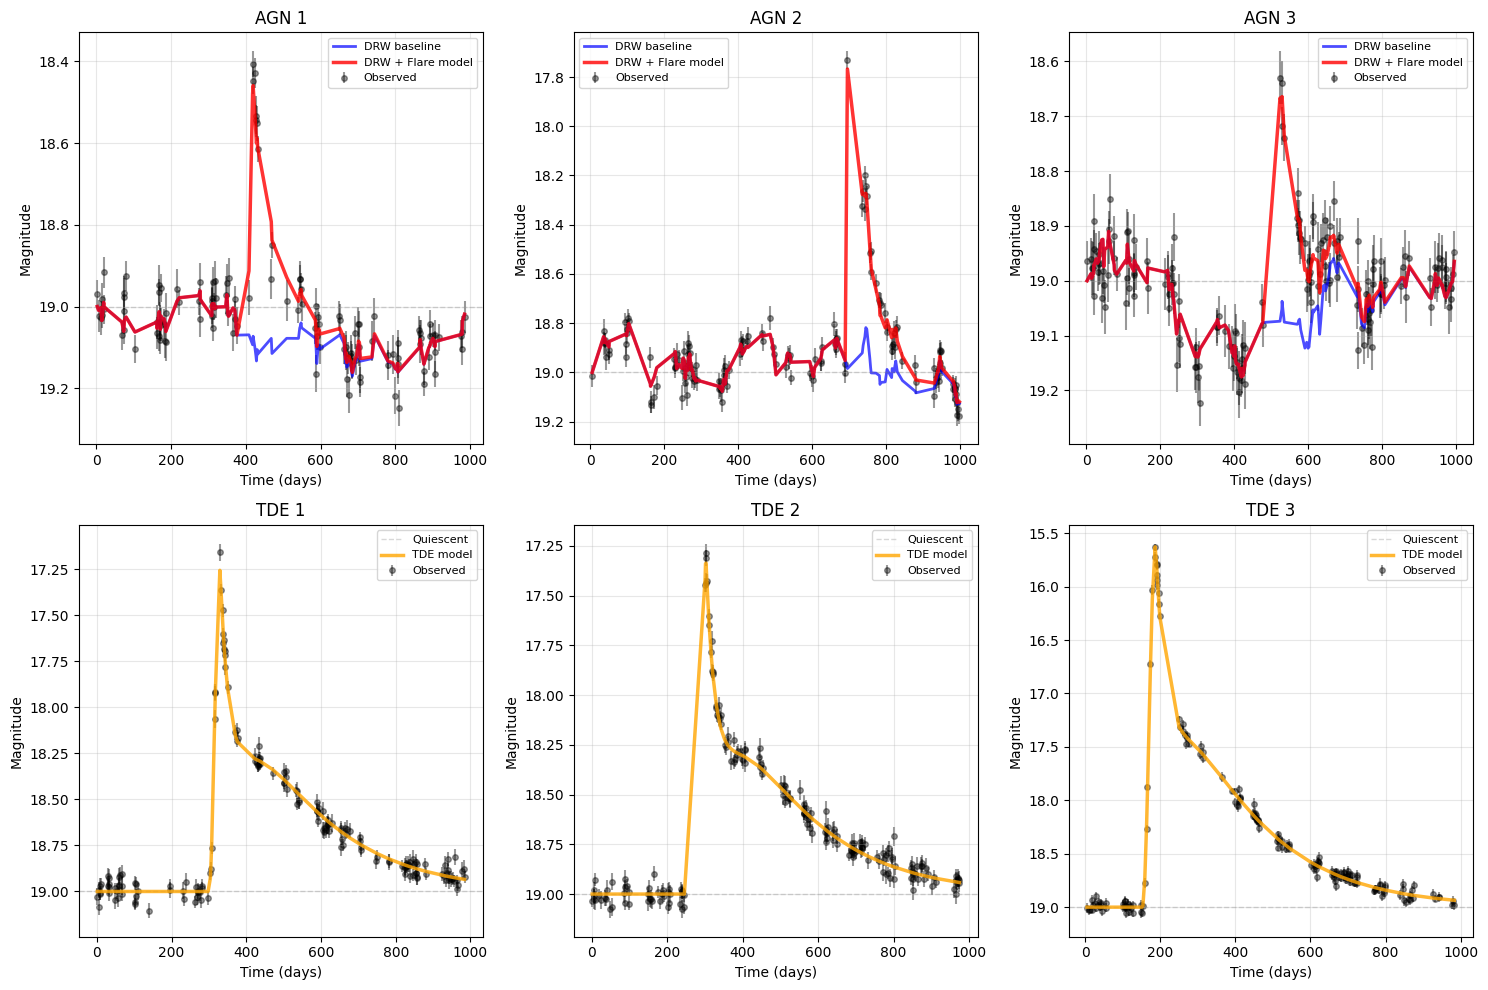

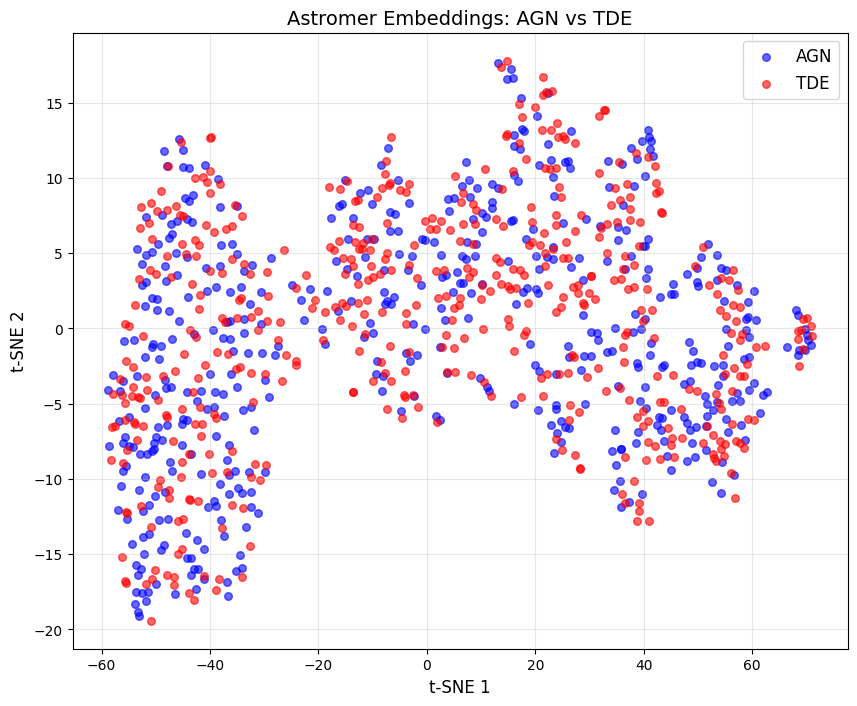


Pipeline complete!

Results available:
  - Light curves: 1000
  - Embeddings: (1000, 1280)
  - Labels: (1000,)
  - Classifier: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [1]:
from fluctuant.pipelines import SyntheticAstromerPipeline, ImprovedAstromerPipeline


def run_synthetic_experiment():
    # Initialize pipeline
    pipeline = ImprovedAstromerPipeline(seed=42)

    # Run everything
    classifier = pipeline.run_full_pipeline(n_agn=500, n_tde=500)

    # Access results
    print("\nResults available:")
    print(f"  - Light curves: {len(pipeline.light_curves)}")
    print(f"  - Embeddings: {pipeline.embeddings.shape}")
    print(f"  - Labels: {pipeline.labels.shape}")
    print(f"  - Classifier: {type(pipeline.classifier)}")

    return pipeline


pipeline = run_synthetic_experiment()